### **Cell 1: Setup and Imports**


In [1]:
# Data Exploration Notebook
# Movie Sentiment Analysis - Phase 2

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from wordcloud import WordCloud
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Imports successful")

✅ Imports successful


In [2]:
# Ensure plots directory exists
from pathlib import Path
PLOTS_DIR = Path("../plots")
PLOTS_DIR.mkdir(exist_ok=True)
print(f"Plots dir ready: {PLOTS_DIR.resolve()}")


Plots dir ready: D:\Project\movie-sentiment-mlops\plots


### **Cell 2: Load Data**

In [3]:
# Load processed data
processed_dir = Path("../data/processed")

train_df = pd.read_csv(processed_dir / "train.csv")
val_df = pd.read_csv(processed_dir / "validation.csv")
test_df = pd.read_csv(processed_dir / "test.csv")

# Load preprocessing stats
with open(processed_dir / "preprocessing_stats.json", 'r') as f:
    stats = json.load(f)

print(f"Train set: {len(train_df):,} samples")
print(f"Val set: {len(val_df):,} samples")
print(f"Test set: {len(test_df):,} samples")
print(f"\nTotal: {len(train_df) + len(val_df) + len(test_df):,} samples")

Train set: 14,000 samples
Val set: 3,000 samples
Test set: 3,000 samples

Total: 20,000 samples


### **Cell 3: Class Distribution**

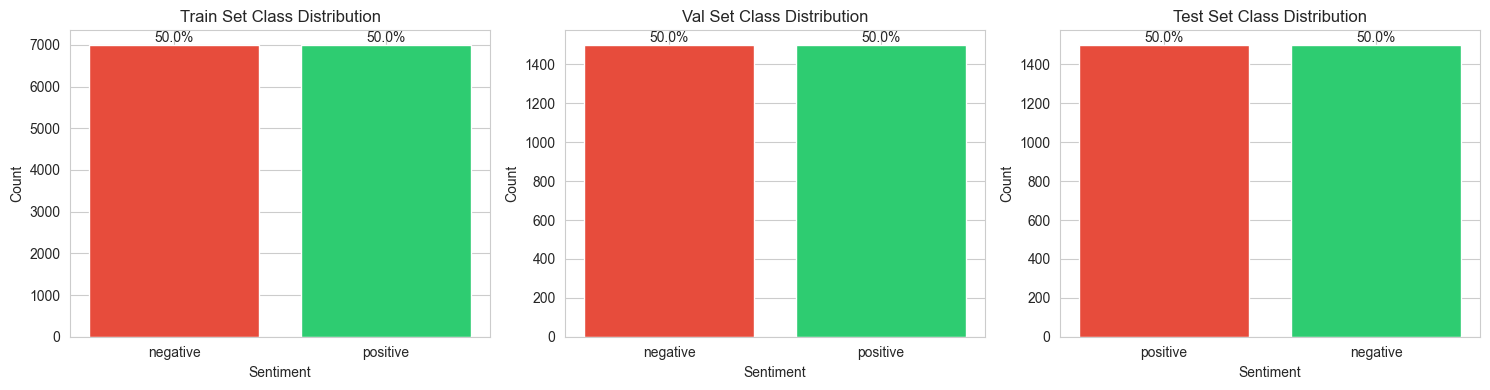

✅ Class distribution perfectly balanced!


In [4]:
# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (df, name) in enumerate([(train_df, 'Train'), (val_df, 'Val'), (test_df, 'Test')]):
    counts = df['sentiment'].value_counts()
    axes[idx].bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'])
    axes[idx].set_title(f'{name} Set Class Distribution')
    axes[idx].set_xlabel('Sentiment')
    axes[idx].set_ylabel('Count')

    # Add percentages
    for i, (label, count) in enumerate(counts.items()):
        pct = count / len(df) * 100
        axes[idx].text(i, count, f'{pct:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../plots/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Class distribution perfectly balanced!")

### **Cell 4: Text Length Analysis**

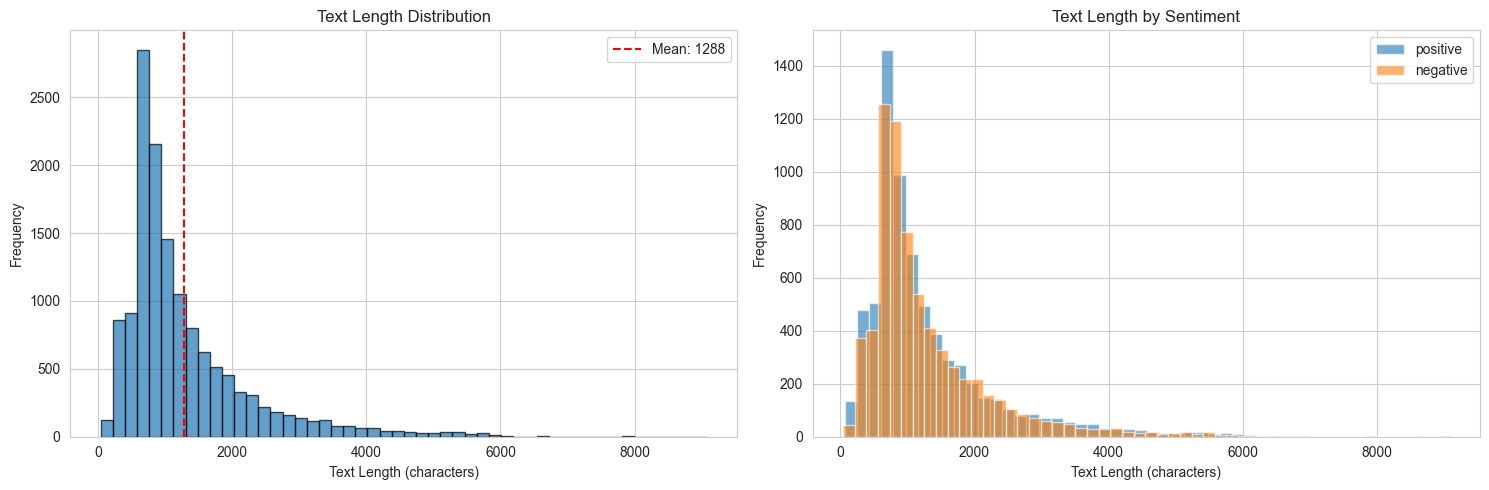

Mean text length: 1288 characters
Median text length: 955 characters


In [5]:
# Text length distribution
train_df['text_length'] = train_df['text_cleaned'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Overall distribution
axes[0].hist(train_df['text_length'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Text Length Distribution')
axes[0].axvline(train_df['text_length'].mean(), color='red',
                linestyle='--', label=f'Mean: {train_df["text_length"].mean():.0f}')
axes[0].legend()

# By sentiment
for sentiment in ['positive', 'negative']:
    subset = train_df[train_df['sentiment'] == sentiment]['text_length']
    axes[1].hist(subset, bins=50, alpha=0.6, label=sentiment)

axes[1].set_xlabel('Text Length (characters)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Text Length by Sentiment')
axes[1].legend()

plt.tight_layout()
plt.savefig('../plots/text_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Mean text length: {train_df['text_length'].mean():.0f} characters")
print(f"Median text length: {train_df['text_length'].median():.0f} characters")

### **Cell 5: Word Clouds**

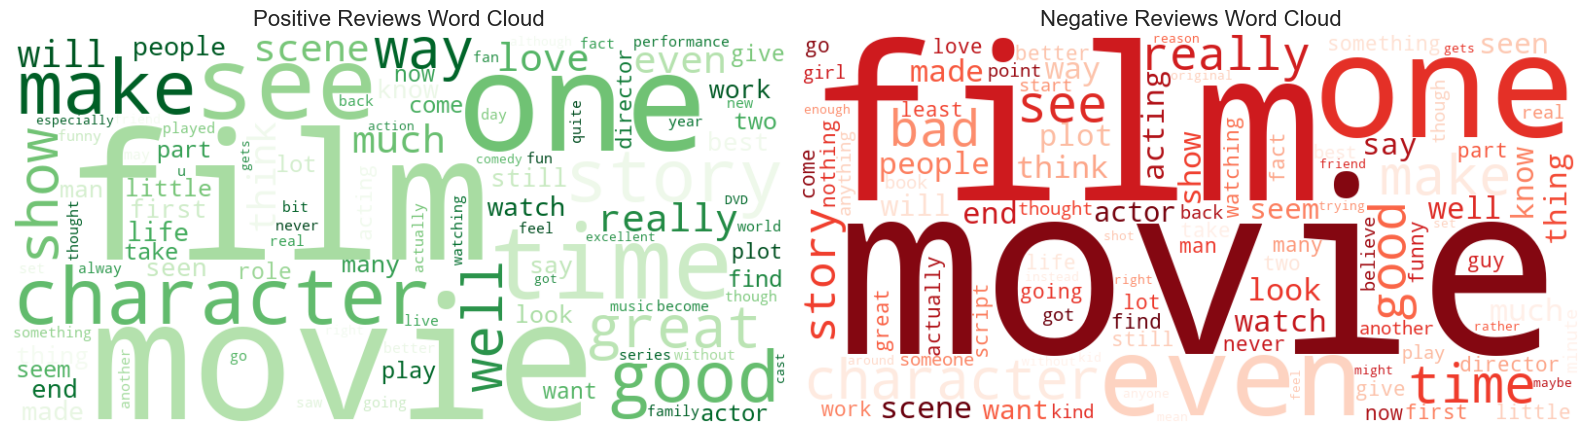

✅ Word clouds generated


In [6]:
# Generate word clouds for positive and negative sentiments
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, sentiment in enumerate(['positive', 'negative']):
    text = ' '.join(train_df[train_df['sentiment'] == sentiment]['text_cleaned'])

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='Greens' if sentiment == 'positive' else 'Reds',
        max_words=100
    ).generate(text)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'{sentiment.capitalize()} Reviews Word Cloud', fontsize=16)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../plots/wordclouds.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Word clouds generated")

### **Cell 6: Summary Statistics**

In [7]:
# Summary statistics table
summary_data = {
    'Metric': [
        'Total Samples',
        'Train Samples',
        'Val Samples',
        'Test Samples',
        'Features (Statistical)',
        'Features (TF-IDF)',
        'Total Features',
        'Avg Text Length',
        'URLs Removed',
        'HTML Tags Removed'
    ],
    'Value': [
        f"{stats['data_shapes']['train'][0] + stats['data_shapes']['val'][0] + stats['data_shapes']['test'][0]:,}",
        f"{stats['data_shapes']['train'][0]:,}",
        f"{stats['data_shapes']['val'][0]:,}",
        f"{stats['data_shapes']['test'][0]:,}",
        stats['feature_counts']['statistical'],
        f"{stats['feature_counts']['tfidf']:,}",
        f"{stats['feature_counts']['total']:,}",
        f"{train_df['text_length'].mean():.0f} chars",
        stats['cleaning_stats']['urls_removed'],
        stats['cleaning_stats']['html_removed']
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*50)
print("PREPROCESSING SUMMARY")
print("="*50)
print(summary_df.to_string(index=False))
print("="*50)


PREPROCESSING SUMMARY
                Metric      Value
         Total Samples     20,000
         Train Samples     14,000
           Val Samples      3,000
          Test Samples      3,000
Features (Statistical)         16
     Features (TF-IDF)      5,000
        Total Features      5,016
       Avg Text Length 1288 chars
          URLs Removed         78
     HTML Tags Removed      19996


### **Cell 7: Save Plots Directory**

In [8]:
# Create plots directory if it doesn't exist
Path("../plots").mkdir(exist_ok=True)
print("✅ EDA complete! Plots saved to plots/ directory")

✅ EDA complete! Plots saved to plots/ directory
